# Eddy-Current Signal Demodulation & Defect Detection

Processes `data/EC-Signal-Tx-19_98-kHz.txt` following the two-stage demodulation
pipeline documented in `CLAUDE.md`:

1. **Stage 1** — for each complete Tx period (~50 samples), take `max - min` of the
   received signal. Each difference is one amplitude point; the result is a sinusoid
   at nearly 20 kHz.
2. **Stage 2** — demodulate (envelope-detect) that sinusoid to get the probe
   variation as it passes over a defect.
3. **Defect** — a single low-frequency sinusoidal pulse (tens...hundreds of Hz) that
   must be identified in the stage-2 output.

> Run from the project root with the `.venv` kernel.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, sosfiltfilt

# --- Acquisition constants (see CLAUDE.md) ---
ADC_CLOCK_HZ = 1_000_000      # 1 MHz ADC clock -> 1 us per sample
TX_FREQ_HZ = 19_980          # Tx carrier (from the data file name)

# Resolve the data file relative to the project root (notebook lives in notebooks/).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "EC-Signal-Tx-19_98-kHz.txt"
DATA_PATH

WindowsPath('N:/github.com/gfeyer/bu_dsp_sandbox/data/EC-Signal-Tx-19_98-kHz.txt')

## 1. Load the data

Two comma-separated integer columns, no header:
- column 1 — received signal, 12-bit (0–4095)
- column 2 — Tx excitation, rectangular (0/1)

In [2]:
raw = np.loadtxt(DATA_PATH, delimiter=",")
signal = raw[:, 0]
tx = raw[:, 1].astype(np.int8)

n = signal.size
t = np.arange(n) / ADC_CLOCK_HZ  # seconds

print(f"samples      : {n}")
print(f"duration     : {n / ADC_CLOCK_HZ * 1e3:.2f} ms")
print(f"signal range : {signal.min():.0f} .. {signal.max():.0f} (12-bit)")
print(f"tx values    : {np.unique(tx)}")

samples      : 300000
duration     : 300.00 ms
signal range : 93 .. 4028 (12-bit)
tx values    : [0 1]


## 2. Explore the raw signal

Zoom into the first few Tx periods to see the carrier riding on the square-wave
excitation and confirm the ~50-samples-per-period assumption.

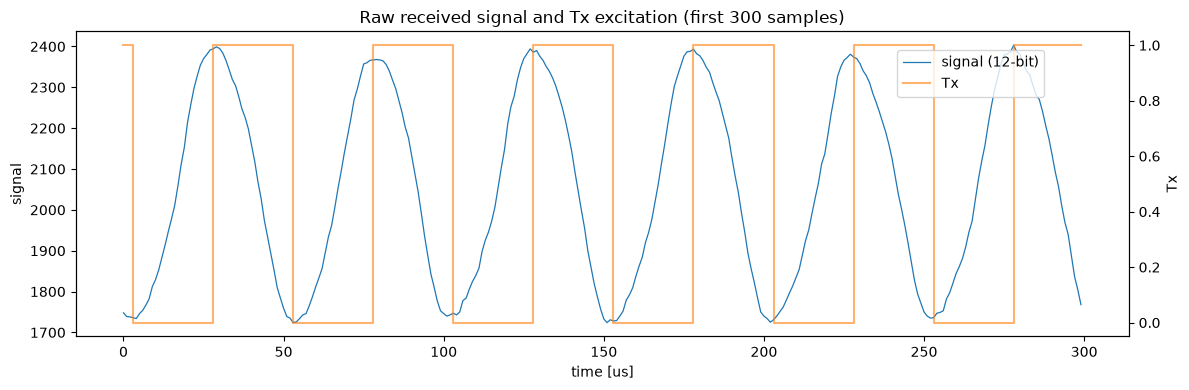

In [3]:
win = slice(0, 300)  # first 300 samples ~= 6 Tx periods

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t[win] * 1e6, signal[win], lw=0.9, label="signal (12-bit)")
ax2 = ax.twinx()
ax2.step(t[win] * 1e6, tx[win], where="post", color="tab:orange", alpha=0.6, label="Tx")
ax.set_xlabel("time [us]")
ax.set_ylabel("signal")
ax2.set_ylabel("Tx")
ax.set_title("Raw received signal and Tx excitation (first 300 samples)")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

## 3. Stage-1 demodulation — peak-to-peak per Tx period

Segment the signal on the **rising edges** of the Tx square wave. Each segment is one
complete Tx period; `max - min` over it gives one amplitude point. The resulting
amplitude series is sampled at the Tx rate (~20 kHz effective).

In [4]:
def demod_peak_to_peak(sig, tx):
    """max-min of `sig` over each Tx period (Tx rising edge -> next rising edge).

    Returns (amp, centers) where `centers` are the sample indices at each period's
    midpoint, suitable for building a time axis.
    """
    edges = np.flatnonzero(np.diff(tx) == 1) + 1  # rising edges of the square wave
    amp = np.empty(edges.size - 1)
    centers = np.empty(edges.size - 1)
    for i in range(edges.size - 1):
        a, b = edges[i], edges[i + 1]
        seg = sig[a:b]
        amp[i] = seg.max() - seg.min()
        centers[i] = (a + b) / 2
    return amp, centers


amp1, centers1 = demod_peak_to_peak(signal, tx)

# Effective sample rate of the stage-1 series (one point per Tx period).
spp = np.diff(centers1).mean()  # samples per period
fs1 = ADC_CLOCK_HZ / spp
t1 = centers1 / ADC_CLOCK_HZ

print(f"periods found        : {amp1.size}")
print(f"samples per Tx period: {spp:.2f}  (-> {ADC_CLOCK_HZ / spp / 1e3:.2f} kHz Tx)")
print(f"stage-1 sample rate  : {fs1 / 1e3:.2f} kHz")

periods found        : 5993
samples per Tx period: 50.05  (-> 19.98 kHz Tx)
stage-1 sample rate  : 19.98 kHz


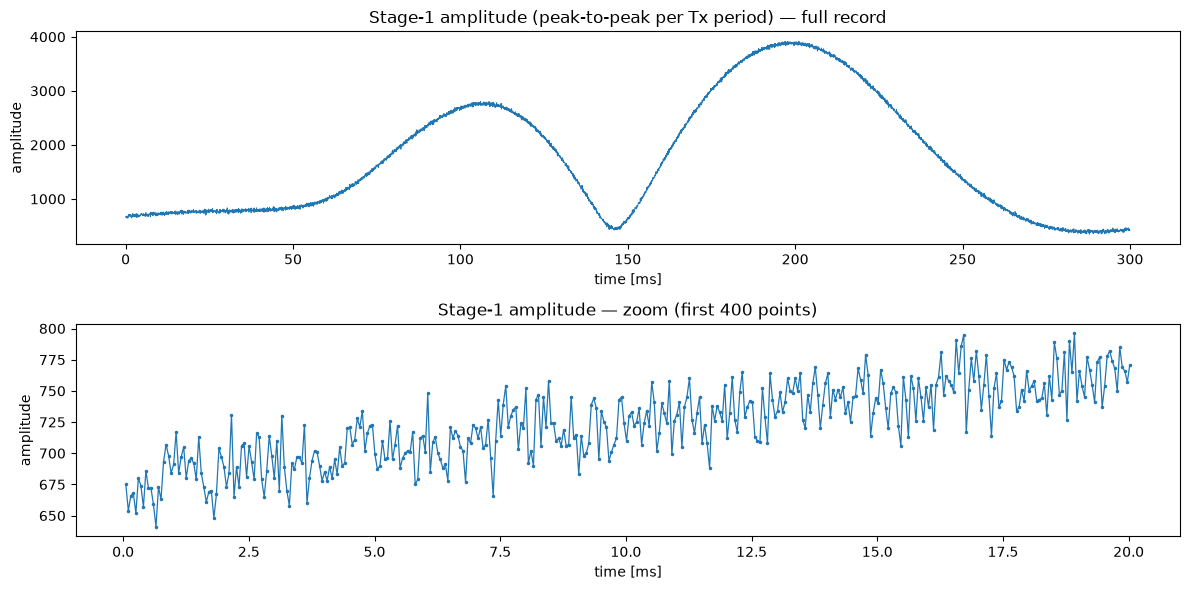

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t1 * 1e3, amp1, lw=0.6)
axes[0].set_title("Stage-1 amplitude (peak-to-peak per Tx period) — full record")
axes[0].set_xlabel("time [ms]")
axes[0].set_ylabel("amplitude")

zoom = slice(0, 400)
axes[1].plot(t1[zoom] * 1e3, amp1[zoom], lw=0.9, marker=".", ms=3)
axes[1].set_title("Stage-1 amplitude — zoom (first 400 points)")
axes[1].set_xlabel("time [ms]")
axes[1].set_ylabel("amplitude")
plt.tight_layout()
plt.show()

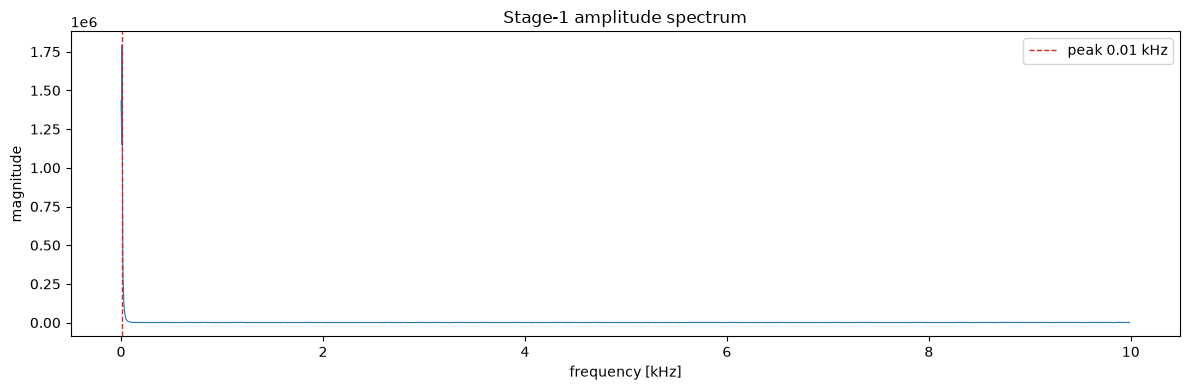

dominant stage-1 frequency: 0.010 kHz


In [6]:
# Confirm the dominant frequency of the stage-1 signal via FFT.
x = amp1 - amp1.mean()
spec = np.abs(np.fft.rfft(x * np.hanning(x.size)))
freqs = np.fft.rfftfreq(x.size, d=1 / fs1)
peak = freqs[np.argmax(spec)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs / 1e3, spec, lw=0.8)
ax.axvline(peak / 1e3, color="tab:red", ls="--", lw=1, label=f"peak {peak/1e3:.2f} kHz")
ax.set_xlabel("frequency [kHz]")
ax.set_ylabel("magnitude")
ax.set_title("Stage-1 amplitude spectrum")
ax.legend()
plt.tight_layout()
plt.show()
print(f"dominant stage-1 frequency: {peak/1e3:.3f} kHz")

## 4. Stage-2 demodulation — envelope of the stage-1 sinusoid

Demodulate the ~20 kHz stage-1 sinusoid to recover its envelope (the probe variation).
The analytic envelope via the Hilbert transform gives the instantaneous amplitude;
the defect appears as a localized deviation on top of the slowly-varying baseline.

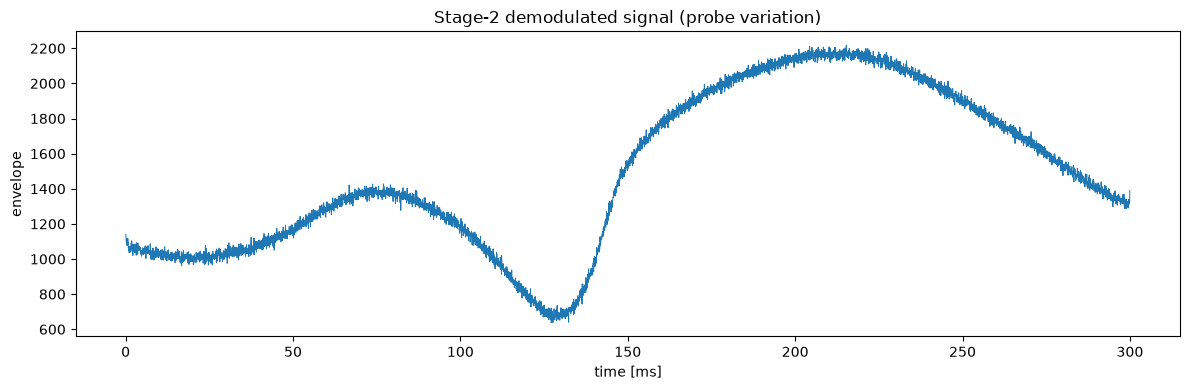

In [7]:
amp2 = np.abs(hilbert(amp1 - amp1.mean()))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t1 * 1e3, amp2, lw=0.7)
ax.set_xlabel("time [ms]")
ax.set_ylabel("envelope")
ax.set_title("Stage-2 demodulated signal (probe variation)")
plt.tight_layout()
plt.show()

## 5. Defect detection — single low-frequency sinusoidal pulse

The defect is a single low-frequency (tens...hundreds of Hz) sinusoidal pulse. Band-pass
the stage-2 signal to that range, take the analytic amplitude (local energy), and flag
the strongest localized burst. **Tune `LO`/`HI` and the threshold against the data.**

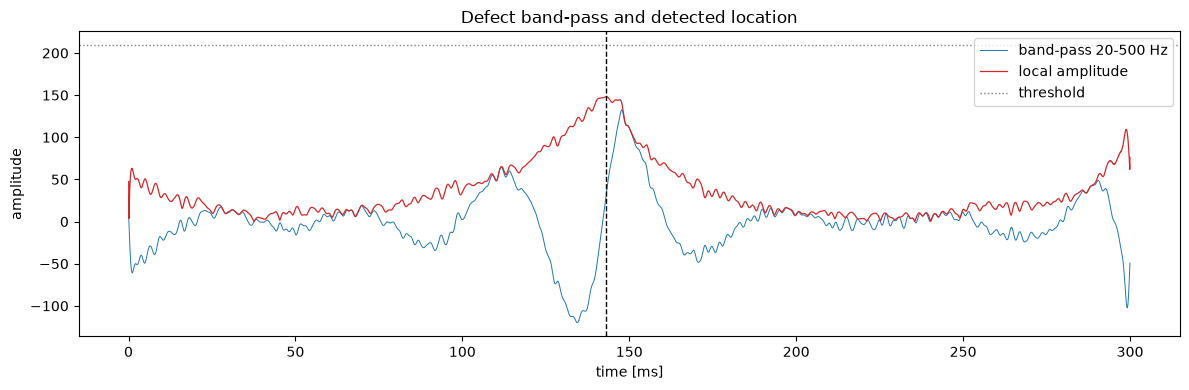

peak energy at t = 143.10 ms (sample 143101)
peak / threshold   = 148 / 209
defect detected    : False


In [8]:
LO, HI = 20.0, 500.0  # Hz — defect band (tune against the data)

sos = butter(4, [LO, HI], btype="band", fs=fs1, output="sos")
band = sosfiltfilt(sos, amp2 - amp2.mean())
energy = np.abs(hilbert(band))

thr = energy.mean() + 5 * energy.std()
peak_idx = int(np.argmax(energy))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t1 * 1e3, band, lw=0.7, label=f"band-pass {LO:.0f}-{HI:.0f} Hz")
ax.plot(t1 * 1e3, energy, lw=0.9, color="tab:red", label="local amplitude")
ax.axhline(thr, color="gray", ls=":", lw=1, label="threshold")
ax.axvline(t1[peak_idx] * 1e3, color="k", ls="--", lw=1)
ax.set_xlabel("time [ms]")
ax.set_ylabel("amplitude")
ax.set_title("Defect band-pass and detected location")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

detected = energy[peak_idx] > thr
print(f"peak energy at t = {t1[peak_idx]*1e3:.2f} ms (sample {int(centers1[peak_idx])})")
print(f"peak / threshold   = {energy[peak_idx]:.3g} / {thr:.3g}")
print(f"defect detected    : {bool(detected)}")

## Notes / next steps

- Verify the stage-1 spectrum peak against the email's "nearly 20 kHz" claim; if the
  per-period sampling aliases the carrier, consider a sliding-window peak-to-peak
  detector at the full 1 MHz rate instead.
- Tune the defect band (`LO`/`HI`) and threshold once the defect's true frequency and
  location are confirmed visually.
- Factor the demodulation helpers into a reusable module if the pipeline stabilizes.